# 11 - Phase 4: LODO threshold matrix, position/length sweep, shift magnitude
Three rigor experiments.
- **Part A (no GPU, cached scores): LODO source-threshold matrix.** Set the operating point on each source in turn and transport to every target; report the gap to the oracle (re-tuned on the target). Establishes that the single-source result is not a lucky source choice.
- **Part B (GPU): position/length sweep.** Resolves the Section 4.8 confound: is ProtectAI-v2's score drop on embedding caused by benign context (camouflage) or just by length? Embed the same instruction in coherent vs neutral filler of matched length.
- **Part C (GPU): adversarial-validation shift magnitude.** Train a source-vs-target discriminator on embeddings; its AUC is a scalar shift distance. Show the collapse scales with measurable shift, not just per-pair anecdote.

## Bootstrap

In [1]:
# === SESSION BOOTSTRAP (run first) ===
from google.colab import drive
drive.mount('/content/drive')
import os, sys
DRIVE_ROOT = '/content/drive/MyDrive/PICALIB_Research'
REPO_DIR = os.path.join(DRIVE_ROOT, 'picalib-research')
!git config --global user.name  "Md Anas Biswas"
!git config --global user.email "anasbiswas@gmail.com"
!git config --global credential.helper "store --file={DRIVE_ROOT}/.git-credentials"
%cd {REPO_DIR}
sys.path.insert(0, 'src')
!git pull
print('Session ready.')

Mounted at /content/drive
/content/drive/MyDrive/PICALIB_Research/picalib-research
Already up to date.
Session ready.


# PART A - LODO source-threshold matrix (cached scores, no GPU)

In [2]:
import importlib, data_loaders, detectors, metrics
for m in (data_loaders, detectors, metrics): importlib.reload(m)
from data_loaders import load_deepset, load_bipia_categorized, load_notinject, load_jailbreak, BIPIA_HARMFUL, BIPIA_HIJACK, BIPIA_MALICIOUS
from detectors import threshold_at_fpr
from metrics import fnr, severity_S
import numpy as np, pandas as pd, os

deepset=load_deepset(); bip=load_bipia_categorized(per_category=30,categories=BIPIA_MALICIOUS); noti=load_notinject()
jb=load_jailbreak(); yd=deepset.label.values
DET={'protectai_v2':'data/score_protectai_v2','prompt_guard_2':'data/score_prompt_guard_2','prompt_guard_2_22m':'data/score_prompt_guard_2_22m'}
H=bip.meta.isin(BIPIA_HARMFUL).values; J=bip.meta.isin(BIPIA_HIJACK).values; bben=bip.label.values==0
def load_scores(base):
    return {'deepset':np.load(base+'_deepset.npy'),'bipia_cat':np.load(base+'_bipia_cat.npy'),
            'jailbreak':np.load(base+'_jailbreak.npy'),'notinject':np.load(base+'_notinject.npy')}
# benign score pools (sources) and target (attacks, benigns) per shift
def pools(S):
    ben={'deepset':S['deepset'][yd==0],'jailbreak':S['jailbreak'][jb.label.values==0],
         'bipia_host':S['bipia_cat'][bben],'notinject':S['notinject']}
    tgt={'direct':(np.ones((yd==1).sum()),S['deepset'][yd==1],S['deepset'][yd==0]),
         'indirect_harmful':(np.ones(H.sum()),S['bipia_cat'][H],S['bipia_cat'][bben]),
         'indirect_hijack':(np.ones(J.sum()),S['bipia_cat'][J],S['bipia_cat'][bben]),
         'jailbreak':(np.ones((jb.label.values==1).sum()),S['jailbreak'][jb.label.values==1],S['jailbreak'][jb.label.values==0])}
    return ben,tgt
print('Part A ready')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/500 [00:00<?, ?B/s]

data/train-00000-of-00001-9564e8b05b4757(…):   0%|          | 0.00/40.3k [00:00<?, ?B/s]

data/test-00000-of-00001-701d16158af8736(…):   0%|          | 0.00/10.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/546 [00:00<?, ? examples/s]

...

jailbreak_dataset_train_balanced.csv:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

jailbreak_dataset_test_balanced.csv:   0%|          | 0.00/370k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1044 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/262 [00:00<?, ? examples/s]

Part A ready


In [3]:
# FNR of each target's attacks at thresholds set on each source benign pool (1% FPR);
# oracle = threshold on the target's OWN benigns.
rows=[]
for det,base in DET.items():
    S=load_scores(base); ben,tgt=pools(S)
    tset={s:threshold_at_fpr(b,0.01) for s,b in ben.items()}
    for tname,(ya,pa,pb) in tgt.items():
        t_oracle=threshold_at_fpr(pb,0.01)
        fnr_oracle=float((pa<t_oracle).mean())
        row={'detector':det,'target':tname,'oracle_t':round(float(t_oracle),4),'FNR_oracle':round(fnr_oracle,3)}
        for s,t in tset.items():
            row[f'FNR|src={s}']=round(float((pa<t).mean()),3)
        rows.append(row)
lodo=pd.DataFrame(rows)
pd.set_option('display.width',200)
print(lodo.to_string(index=False))

          detector           target  oracle_t  FNR_oracle  FNR|src=deepset  FNR|src=jailbreak  FNR|src=bipia_host  FNR|src=notinject
      protectai_v2           direct    0.0275       0.548            0.548              0.559               0.825              0.954
      protectai_v2 indirect_harmful    1.0000       0.983            0.650              0.667               0.983              1.000
      protectai_v2  indirect_hijack    1.0000       0.993            0.693              0.747               0.993              1.000
      protectai_v2        jailbreak    0.0525       0.141            0.136              0.141               0.581              0.947
    prompt_guard_2           direct    0.0035       0.532            0.532              0.711               0.643              0.844
    prompt_guard_2 indirect_harmful    0.0125       0.683            0.217              0.850               0.683              1.000
    prompt_guard_2  indirect_hijack    0.0125       0.960            

In [4]:
# Source-vs-oracle gap: how much worse is transporting a frozen source threshold than re-tuning on target.
gap=[]
for _,r in lodo.iterrows():
    for s in ['deepset','jailbreak','bipia_host','notinject']:
        gap.append({'detector':r['detector'],'target':r['target'],'source':s,
                    'FNR_src':r[f'FNR|src={s}'],'FNR_oracle':r['FNR_oracle'],
                    'gap':round(r[f'FNR|src={s}']-r['FNR_oracle'],3)})
gapdf=pd.DataFrame(gap)
print('Mean source-threshold FNR gap vs oracle, by target (positive = source threshold misses MORE):')
print(gapdf.groupby('target')['gap'].agg(['mean','min','max']).round(3).to_string())
print('\nThe deepset-source row is the panel threshold used in the main paper.')

Mean source-threshold FNR gap vs oracle, by target (positive = source threshold misses MORE):
                   mean    min    max
target                               
direct            0.127  0.000  0.406
indirect_harmful -0.039 -0.466  0.317
indirect_hijack  -0.063 -0.300  0.040
jailbreak         0.079 -0.190  0.806

The deepset-source row is the panel threshold used in the main paper.


# PART B - position/length sweep (resolves the Section 4.8 confound)
GPU needed (encoder scoring of new texts).

In [5]:
!pip install -q transformers sentencepiece
import torch; print('CUDA:',torch.cuda.is_available())

CUDA: True


In [6]:
from data_loaders import _bipia_attacks_by_cat, _bipia_contexts
from detectors import score_released
import random
WORK='/content/_bipia'
cats=_bipia_attacks_by_cat(WORK); ctxs=_bipia_contexts(WORK); random.Random(0).shuffle(ctxs)
instrs=[]
for c in BIPIA_HIJACK:
    instrs+=[a for a in cats.get(c,[]) if 5<len(a)<200]
instrs=list(dict.fromkeys(instrs))[:15]
NEUTRAL=('The quarterly summary notes routine operations and no items requiring attention. ')
def coherent(n):    # first n chars of a real benign host doc
    s=''.join(ctxs)[:max(n,1)]; return s[:n]
def neutral(n):     # neutral benign filler padded to n chars
    s=(NEUTRAL*((n//len(NEUTRAL))+1))[:n]; return s
LENS=[0,100,300,600]
rows=[]
for ins in instrs:
    for L in LENS:
        for ftype,fn in [('coherent',coherent),('neutral',neutral)]:
            f=fn(L)
            if L==0:
                rows.append({'instr':ins,'len':0,'ftype':'none','pos':'none','text':ins}); continue
            rows.append({'instr':ins,'len':L,'ftype':ftype,'pos':'end','text':f+'\n'+ins})
            rows.append({'instr':ins,'len':L,'ftype':ftype,'pos':'start','text':ins+'\n'+f})
sweep=pd.DataFrame(rows).drop_duplicates('text').reset_index(drop=True)
print('sweep texts:',len(sweep)); print(sweep.groupby(['len','ftype','pos']).size())

sweep texts: 195
len  ftype     pos  
0    none      none     15
100  coherent  end      15
               start    15
     neutral   end      15
               start    15
300  coherent  end      15
               start    15
     neutral   end      15
               start    15
600  coherent  end      15
               start    15
     neutral   end      15
               start    15
dtype: int64


In [7]:
from huggingface_hub import login; import getpass
_t=getpass.getpass('HF token (Prompt-Guard; blank=ProtectAI only): ').strip()
if _t: login(token=_t)
SWD={'protectai_v2':'protectai/deberta-v3-base-prompt-injection-v2','prompt_guard_2':'meta-llama/Llama-Prompt-Guard-2-86M'}
os.makedirs('data/phase4',exist_ok=True)
for tag,name in SWD.items():
    fp=f'data/phase4/sweep_{tag}.npy'
    if os.path.exists(fp): sweep[tag]=np.load(fp)
    else:
        try: sweep[tag]=score_released(sweep.text.tolist(),name); np.save(fp,sweep[tag].values)
        except Exception as e: print('[skip]',tag,e)
print('scored sweep')

HF token (Prompt-Guard; blank=ProtectAI only): ··········


config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  meta-llama/Llama-Prompt-Guard-2-86M: id2label={0: 'LABEL_0', 1: 'LABEL_1'} -> attack class index 1
scored sweep


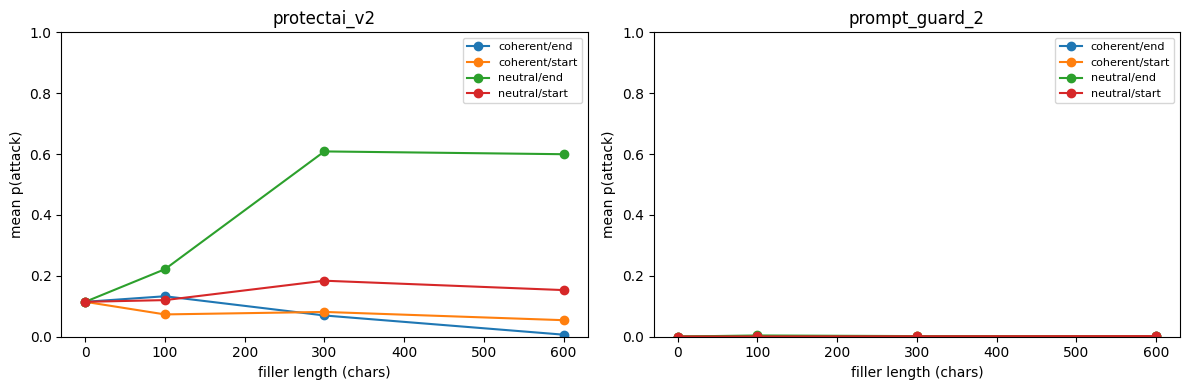

ProtectAI mean p by length x filler (end position):
len  ftype   
0    none        0.115
100  coherent    0.133
     neutral     0.222
300  coherent    0.070
     neutral     0.609
600  coherent    0.007
     neutral     0.600


In [8]:
import matplotlib.pyplot as plt
DETS=[c for c in ['protectai_v2','prompt_guard_2'] if c in sweep.columns]
fig,axes=plt.subplots(1,len(DETS),figsize=(6*len(DETS),4),squeeze=False)
base={d:sweep[sweep.len==0][d].mean() for d in DETS}
for ax,d in zip(axes[0],DETS):
    for ftype in ['coherent','neutral']:
        for pos in ['end','start']:
            xs=[0]; ys=[base[d]]
            for L in [100,300,600]:
                m=sweep[(sweep.len==L)&(sweep.ftype==ftype)&(sweep.pos==pos)]
                xs.append(L); ys.append(m[d].mean())
            ax.plot(xs,ys,marker='o',label=f'{ftype}/{pos}')
    ax.set_title(d); ax.set_xlabel('filler length (chars)'); ax.set_ylabel('mean p(attack)'); ax.set_ylim(0,1); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/phase4_position_length.png',dpi=150); plt.show()
# camouflage test: coherent vs neutral at matched length (end position)
print('ProtectAI mean p by length x filler (end position):')
if 'protectai_v2' in sweep.columns:
    print(sweep[sweep.pos.isin(['end','none'])].groupby(['len','ftype'])['protectai_v2'].mean().round(3).to_string())

In [9]:
# verdict for Part B
vb=[]
if 'protectai_v2' in sweep.columns:
    d='protectai_v2'
    for L in [300,600]:
        coh=sweep[(sweep.len==L)&(sweep.ftype=='coherent')&(sweep.pos=='end')][d].mean()
        neu=sweep[(sweep.len==L)&(sweep.ftype=='neutral')&(sweep.pos=='end')][d].mean()
        vb.append(f'len={L}: coherent p={coh:.3f} vs neutral p={neu:.3f} -> '+('CAMOUFLAGE beyond length (coherent context suppresses more).' if coh<neu-0.03 else 'length dilution dominates (coherent ~ neutral).'))
sweepB='\n'.join(vb); print(sweepB)
sweep.drop(columns='text').to_csv('reports/phase4_position_length.csv',index=False)

len=300: coherent p=0.070 vs neutral p=0.609 -> CAMOUFLAGE beyond length (coherent context suppresses more).
len=600: coherent p=0.007 vs neutral p=0.600 -> CAMOUFLAGE beyond length (coherent context suppresses more).


# PART C - adversarial-validation shift magnitude
GPU helpful (embeddings). Train source-vs-target discriminator; AUC = shift distance.

In [ ]:
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
emb=SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
def E(texts): return emb.encode(list(texts),batch_size=64,show_progress_bar=False,normalize_embeddings=True)
src=deepset[deepset.label==1].text.tolist()   # direct attacks = source
TGT={'indirect_harmful':bip[H].text.tolist(),'indirect_hijack':bip[J].text.tolist(),
     'jailbreak':jb[jb.label==1].text.tolist()}
Es=E(src)
shift=[]
for name,tt in TGT.items():
    Et=E(tt)
    X=np.vstack([Es,Et]); y=np.r_[np.zeros(len(Es)),np.ones(len(Et))]
    auc=cross_val_score(LogisticRegression(max_iter=1000),X,y,cv=5,scoring='roc_auc').mean()
    shift.append({'target':name,'shift_magnitude_AUC':round(float(auc),3),'n_src':len(Es),'n_tgt':len(Et)})
shiftdf=pd.DataFrame(shift); print(shiftdf.to_string(index=False))
print('\nAUC near 0.5 = indistinguishable from source (small shift); near 1.0 = large shift.')

In [ ]:
# relate shift magnitude to the collapse (mean encoder AUROC drop on that target)
panel=pd.read_csv('reports/transport_panel.csv')
direct_auroc=panel[panel['shift']=='direct'].groupby('detector')['AUROC'].mean()
coll=[]
for name in shiftdf.target:
    sub=panel[panel['shift']==name]
    mean_auroc=sub['AUROC'].mean(); mean_fnr=sub['FNR'].mean()
    coll.append({'target':name,'mean_AUROC':round(mean_auroc,3),'mean_FNR':round(mean_fnr,3)})
colldf=pd.DataFrame(coll).merge(shiftdf[['target','shift_magnitude_AUC']],on='target')
colldf=colldf.sort_values('shift_magnitude_AUC')
print(colldf.to_string(index=False))
from scipy.stats import spearmanr
if len(colldf)>=3:
    rho,_=spearmanr(colldf['shift_magnitude_AUC'],colldf['mean_AUROC'])
    print(f'\nSpearman(shift_magnitude, mean detector AUROC) = {rho:+.2f} (descriptive, n={len(colldf)})')
    print('Negative -> larger measured shift goes with worse discrimination: collapse scales with shift.')
colldf.to_csv('reports/phase4_shift_magnitude.csv',index=False)

## Persist + commit

In [ ]:
from reslog import log_result
lodo.to_csv('reports/phase4_lodo_matrix.csv',index=False)
body='LODO MATRIX:\n'+lodo.to_string(index=False)
body+='\n\nGAP vs oracle by target:\n'+gapdf.groupby('target')['gap'].agg(['mean','min','max']).round(3).to_string()
try: body+='\n\nPOSITION/LENGTH (Part B):\n'+sweepB
except: pass
try: body+='\n\nSHIFT MAGNITUDE (Part C):\n'+colldf.to_string(index=False)
except: pass
log_result('Phase 4 LODO matrix + position/length + shift magnitude', body, csv_df=lodo, csv_name='phase4_lodo_matrix.csv')
!git add -A && git commit -m "Phase 4: LODO threshold matrix, position/length sweep, adversarial-validation shift magnitude" && git push
print('done')